# Wprowadzenie do sztucznej inteligencji i uczenia maszynowego

### Ćwiczenia 5. — Zadania.

---

In [12]:
from IPython.core.display import HTML


def _set_css_style(css_file_path):
    """
    Read the custom CSS file and load it into Jupyter.
    Pass the file path to the CSS file.
    """

    styles = open(css_file_path, "r").read()
    s = '<style>%s</style>' % styles
    return HTML(s)


_set_css_style("uczenie_maszynowe/custom.css")

#### Zaimportuj biblioteki numpy, pandas, matplotlib i seaborn.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

<div class="alert alert-block alert-info">
ℹ️ W przypadku problemów z działaniem i interakcjami niektórych widgetów w lokalnym środowisku najprostszym rozwiązaniem będzie przeniesienie się na Google Colab.
</div>

#### Załaduj plik csv.
***
Do zmiennej `df` załaduj plik `pokemon.csv`.

In [14]:
df = pd.read_csv('pokemon.csv')
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


Ten zbiór danych zawiera informacje na temat 801 Pokémonów z pierwszych siedmiu generacji. Obejmuje on podstawowe statystyki, osiągi przeciwko innym typom, wzrost, wagę, klasyfikacje punkty doświadczenia, zdolności itp. Informacje zostały pobrane z serwisu serebii (www.serebii.net) i mają następujące cechy:

- abilities: ciąg znaków zawierający listę zdolności, które Pokémon może posiadać.
- against_?: osiemnaście cech, które określają ilość otrzymywanych obrażeń od ataku określonego typu Pokémona.
- attack: podstawowy atak Pokémona.
- base_egg_steps: liczba kroków wymagana do wyklucia się jaja Pokémona.
- base_happiness: podstawowe szczęście Pokémona.
- base_total: suma hp, ataku, obrony, specjalnego ataku, specjalnej obrony i prędkości.
- capture_rate: współczynnik łapania Pokémona.
- classification: klasyfikacja Pokémona, opisana przez Pokédex Sun and Moon.
- defense: podstawowa obrona Pokémona.
- experience_growth: wzrost doświadczenia Pokémona.
- height_m: wysokość Pokémona w metrach.
- hp: podstawowe HP Pokémon. Jest to skrót od Hit Point, który określa, ile obrażeń Pokémon może otrzymać przed omdleniem.
- japanese_name: oryginalna japońska nazwa Pokémona.
- name: angielska nazwa Pokémona.
- percentage_male: procent osobników płci męskiej w gatunku. Puste, jeśli Pokémon jest bezpłciowy.
- pokedex_number: numer wpisu Pokémona w Krajowym Pokédexie.
- sp_attack: podstawowy specjalny atak Pokémona.
- sp_defense: podstawowa specjalna obrona Pokémona.
- speed: podstawowa prędkość Pokémona.
- type1: podstawowy typ Pokémona.
- type2: drugi typ Pokémona.
- weight_kg: waga Pokémona w kilogramach.
- generation: numerowana generacja, w której wprowadzono Pokémona.
- is_legendary: oznacza, czy Pokémon jest legendarny.

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
against_bug,801.0,9.962547e-01,0.597248,0.25,0.5,1.0,1.0,4.0
against_dark,801.0,1.057116e+00,0.438142,0.25,1.0,1.0,1.0,4.0
against_dragon,801.0,9.687890e-01,0.353058,0.00,1.0,1.0,1.0,2.0
against_electric,801.0,1.073970e+00,0.654962,0.00,0.5,1.0,1.0,4.0
against_fairy,801.0,1.068976e+00,0.522167,0.25,1.0,1.0,1.0,4.0
against_fight,801.0,1.065543e+00,0.717251,0.00,0.5,1.0,1.0,4.0
against_fire,801.0,1.135456e+00,0.691853,0.25,0.5,1.0,2.0,4.0
against_flying,801.0,1.192884e+00,0.604488,0.25,1.0,1.0,1.0,4.0
against_ghost,801.0,9.850187e-01,0.558256,0.00,1.0,1.0,1.0,4.0
against_grass,801.0,1.034020e+00,0.788896,0.25,0.5,1.0,1.0,4.0


#### Przygotuj dane.
***
Wykonamy tu następujące czynności:
- wyrzucimy nieinteresujące na kolumny
- zmienimy nazwy kolumny na zaczynające się wielką literą
- wstawimy kolumnę z nazwą Pokémonów na początek
- zmienimy wartości w kolumnie `'Is_Legendary'` na napisy
- zmienimy nazwy typów Pokémonów na zaczynające się wielką literą
- zmienimy dane w kolumnie `'Capture_Rate'` na liczbowe

In [26]:
types = [t for t in list(df['Type1'].unique())]
types

['Grass',
 'Fire',
 'Water',
 'Bug',
 'Normal',
 'Poison',
 'Electric',
 'Ground',
 'Fairy',
 'Fighting',
 'Psychic',
 'Rock',
 'Ghost',
 'Ice',
 'Dragon',
 'Dark',
 'Steel',
 'Flying']

In [ ]:
df = df.drop(
    ['japanese_name', 'pokedex_number', 'base_egg_steps', 'classfication', 'percentage_male'],
    axis=1
)

df = df.rename(str.title, axis='columns')

df = df.reindex(['Name'] + [col for col in df.columns if col != 'Name'], axis=1)

df = df.replace(
    {
        'Is_Legendary': {
            0: "Non-legendary",
            1: "Legendary",
        },
    },
)

types = [t for t in list(df['Type1'].unique())]

df['Type1'] = df['Type1'].replace(types, [t.title() for t in types])
df['Type2'] = df['Type2'].replace(types, [t.title() for t in types])

df['Capture_Rate'] = df['Capture_Rate'].replace({'30 (Meteorite)255 (Core)': np.nan})
df['Capture_Rate'] = pd.to_numeric(df['Capture_Rate'])

#### Dodaj parametry do Seaborna.
***
Dodanie parametrów rysowania w Seabornie pozwala na dostosowanie wyglądu wykresów do naszych preferencji i wymagań.
Ustawienie tych wartości przed utworzeniem wykresów pozwala na utrzymanie spójnego wyglądu między różnymi wykresami.

In [6]:
SEABORN_RC_PARAMS = {
    'font.size': 6,
    'xtick.color': 'gray',
    'xtick.labelsize': 6,
    'ytick.color': 'gray',
    'ytick.labelsize': 6,
    'text.color': 'gray',
    'legend.fontsize': 6,
    'legend.loc': 'upper left',
    'legend.frameon': False,
    'xaxis.labellocation': 'left',
    'yaxis.labellocation': 'top',
    'axes.edgecolor': 'gray',
    'axes.labelcolor': 'gray',
    'axes.titlelocation': 'left',
    'axes.labelsize': 6,
    'axes.titlesize': 12,
    'axes.titlepad': 20,
    'figure.figsize': (6, 3),
    'figure.dpi': 200,
    'figure.titlesize': 12,
}
SEABORN_STYLE = 'white'
sns.set(rc=SEABORN_RC_PARAMS, style=SEABORN_STYLE)

### Rysowanie ładnych wykresów.
***
Poniżej przedstawiam kilka inspirujących przykładów wykresów, które można stworzyć na podstawie danych dotyczących Pokémonów. Przy każdym z tych wykresów warto zwrócić uwagę na kilka elementów:

- W jaki sposób dane są modyfikowane przed stworzeniem wykresu?
- Jaki rodzaj wykresu jest używany i dlaczego taki wybór został dokonany?
- Jakie metody i funkcje są używane do stworzenia danego wykresu?
- Jakie argumenty przyjmują te metody i funkcje?

Jeśli pojawiają się jakieś wątpliwości co do działania danej metody lub argumentu, warto spróbować usunąć go z kodu i zobaczyć, jakie zmiany wpłyną na wykres.

Wykresy te powstały na podstawie notebooka dostępnego pod adresem https://www.kaggle.com/code/joaopdrg/discovering-the-best-pok-mon, gdzie znajduje się więcej przykładów.

#### Przeanalizuj rysowanie wykresu słupkowego z liczbą wystąpień.
***
Wykres przedstawia liczbę nowych Pokémonów w każdej generacji.

/tmp/ipykernel_132340/2464351420.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y="Generation", data=df, orient='h', palette=['indianred', 'indianred', 'indianred', 'indianred', 'darkred', 'indianred', 'indianred'])


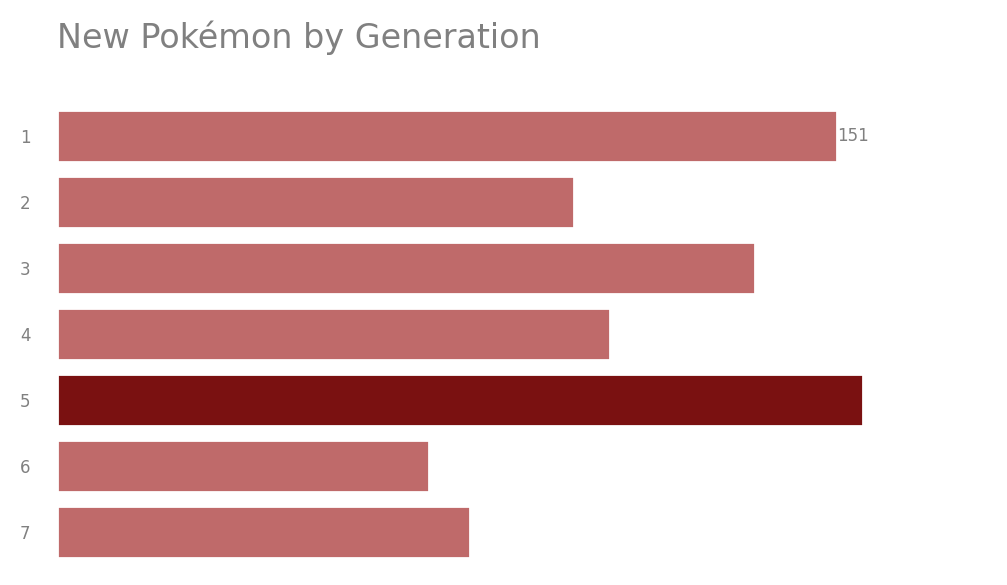

In [7]:
ax = sns.countplot(y="Generation", data=df, orient='h', palette=['indianred', 'indianred', 'indianred', 'indianred', 'darkred', 'indianred', 'indianred'])
ax.set_title('New Pokémon by Generation')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks(ax.get_xticks(), labels='')
sns.despine(top=True, bottom=True, left=True, right=True)
ax.bar_label(ax.containers[0], fmt='%0.f')
plt.show()

#### Przeanalizuj rysowanie wykresu słupkowego.
***
Wykres przedstawia łączną liczbę Pokémonów każdego typu.

In [18]:
df.columns

Index(['Name', 'Abilities', 'Against_Bug', 'Against_Dark', 'Against_Dragon',
       'Against_Electric', 'Against_Fairy', 'Against_Fight', 'Against_Fire',
       'Against_Flying', 'Against_Ghost', 'Against_Grass', 'Against_Ground',
       'Against_Ice', 'Against_Normal', 'Against_Poison', 'Against_Psychic',
       'Against_Rock', 'Against_Steel', 'Against_Water', 'Attack',
       'Base_Happiness', 'Base_Total', 'Capture_Rate', 'Defense',
       'Experience_Growth', 'Height_M', 'Hp', 'Sp_Attack', 'Sp_Defense',
       'Speed', 'Type1', 'Type2', 'Weight_Kg', 'Generation', 'Is_Legendary'],
      dtype='object')

In [20]:
type1_value_counts = df['Type1'].value_counts()
type2_value_counts = df['Type2'].value_counts()

types_df = pd.concat([type1_value_counts, type2_value_counts], axis=1)

types_df.columns = ['Type1', 'Type2']

types_df.sort_values(by='Type2', ascending=True, inplace=True)
types_df

,Type1,Type2
Normal,105,4
Bug,72,5
Electric,39,9
Fire,52,13
Rock,45,14
Ghost,27,14
Ice,23,15
Water,114,17
Dragon,27,17
Grass,78,20


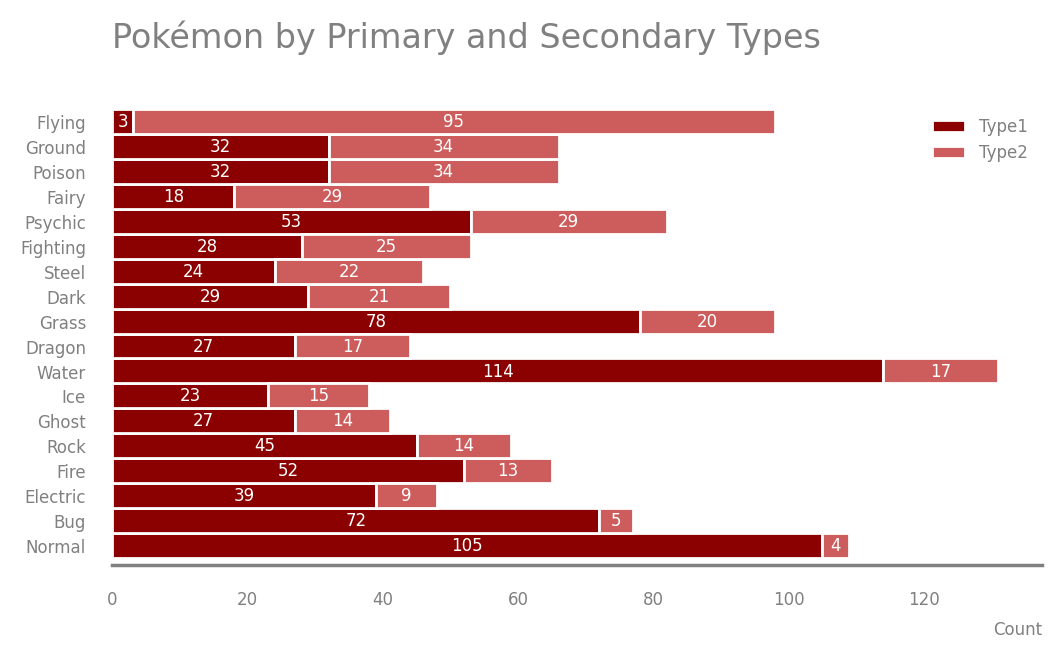

In [21]:
ax = types_df.plot(
        kind= 'barh',
        stacked= True,
        color= ['darkred', 'indianred'],
        width= 1
)
ax.set_title('Pokémon by Primary and Secondary Types')
ax.set_xlabel('Count', loc='right')
sns.despine(top=True, left=True, right=True)
for container in ax.containers:
    ax.bar_label(
            container,
            fmt= '%0.f',
            color='white',
            label_type= 'center'
    )

#### Przeanalizuj rysowanie pudełkowego.
***
Wykres powinien przedstawiać zależność współczynnika łapania Pokémonów dla każdego typu z podziałem na Pokémony legendarne.

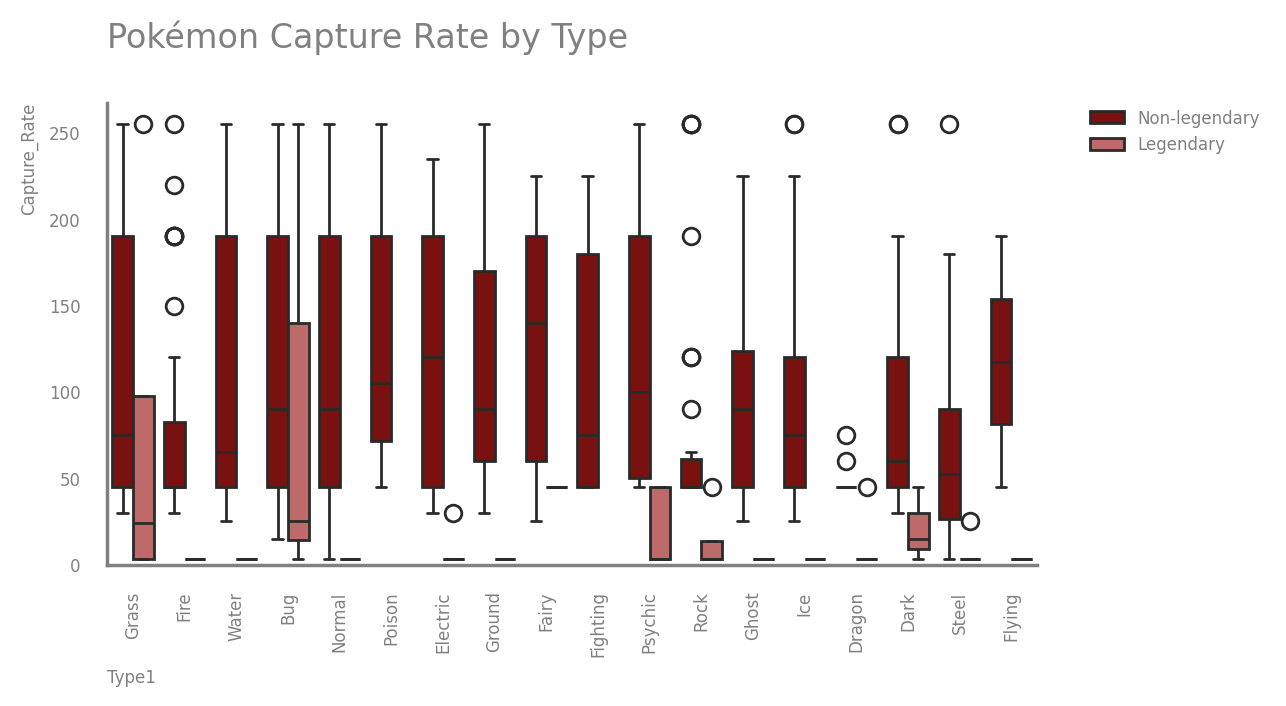

In [22]:
ax=sns.boxplot(
        df,
        x= 'Type1',
        y= 'Capture_Rate',
        hue= 'Is_Legendary',
        palette= ['darkred', 'indianred']
    )
ax.set_title('Pokémon Capture Rate by Type')
plt.ylim(bottom=0)
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
sns.despine()

#### Przeanalizuj rysowanie wykresu punktowego.
***
Wykres przedstawia zależność wzrostu od wagi dla każdego Pokémona z podziałem na legendarne.

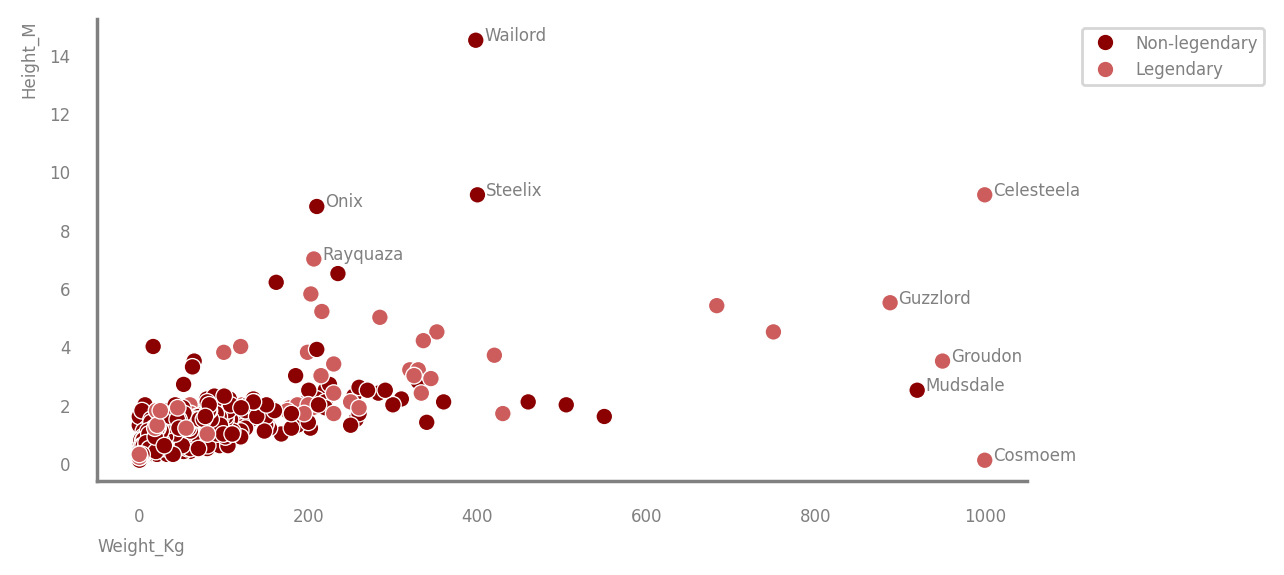

In [23]:
sns.scatterplot(
    df,
    x= 'Weight_Kg',
    y= 'Height_M',
    hue= 'Is_Legendary',
    palette= ['darkred', 'indianred']
)
ax.set_title('Pokémon by Weight and Height')
sns.despine()
plt.legend(frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.5)
legend_kws={
    'borderpad': 0,
    'markerscale': 0.5,
    'handlelength': 0,
},
plot_average=False

# Label top 5 by weight and height
top5_weight_height_merged = pd.concat([
    df.nlargest(5, 'Height_M'),
    df.nlargest(5, 'Weight_Kg'),
]).drop_duplicates(subset=['Name'])
for index, row in top5_weight_height_merged.iterrows():
    plt.annotate(row['Name'], xy=(row['Weight_Kg']+10, row['Height_M']))

#### Przeanalizuj rysowanie mapy ciepła.
***
Wykres przedstawia efektywność każdego typu Pokémonów.

In [24]:
against_columns = [
    'Against_Bug',
    'Against_Dark',
    'Against_Dragon',
    'Against_Electric',
    'Against_Fairy',
    'Against_Fight',
    'Against_Fire',
    'Against_Flying',
    'Against_Ghost',
    'Against_Grass',
    'Against_Ground',
    'Against_Ice',
    'Against_Normal',
    'Against_Poison',
    'Against_Psychic',
    'Against_Rock',
    'Against_Steel',
    'Against_Water',
]

pokemon_type_effectiveness = df.groupby(['Type1']).median(numeric_only=True)[against_columns]

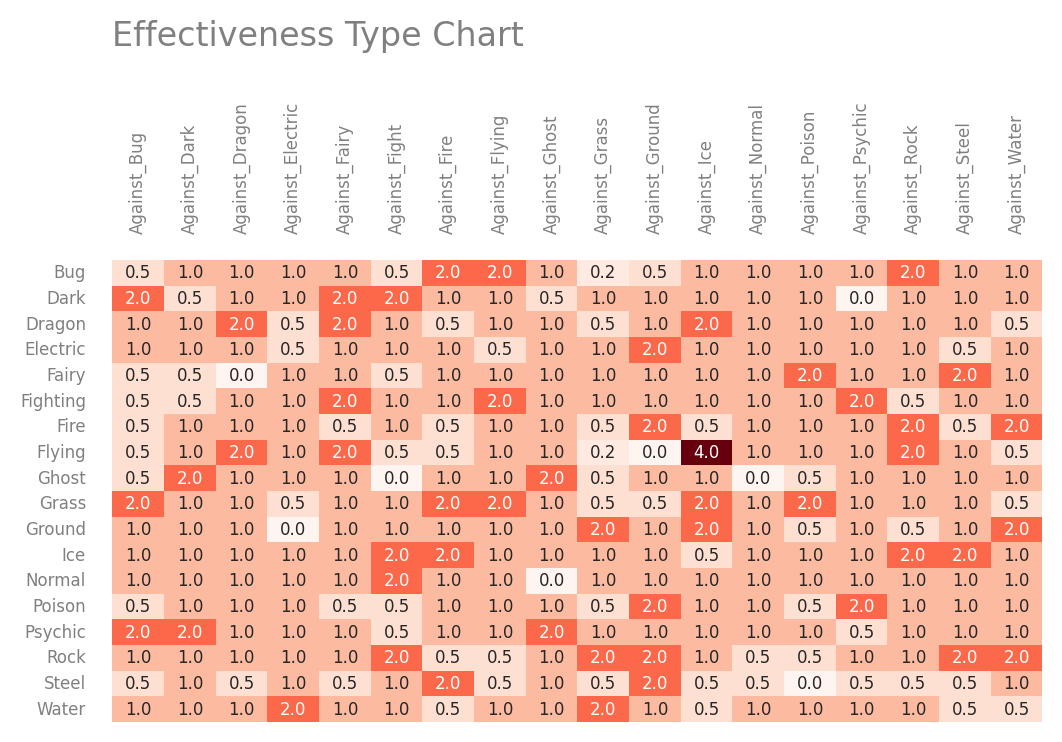

In [25]:
ax = sns.heatmap(
    pokemon_type_effectiveness,
    annot= True,
    cbar= False,
    cmap= 'Reds',
    fmt= '.1f',
    vmin= 0,
    vmax= 4
)
ax.set_title('Effectiveness Type Chart')
ax.set_xlabel('')
ax.set_ylabel('')
ax.xaxis.tick_top()
plt.tick_params(top=False)
plt.xticks(rotation=90)
plt.show()

#### Narysuj wykres pudełkowy.
***
Wykres przedstawia zależność współczynnika łapania Pokémonów dla każdej generacji z podziałem na Pokémony legendarne.

In [27]:
df.columns

Index(['Name', 'Abilities', 'Against_Bug', 'Against_Dark', 'Against_Dragon',
       'Against_Electric', 'Against_Fairy', 'Against_Fight', 'Against_Fire',
       'Against_Flying', 'Against_Ghost', 'Against_Grass', 'Against_Ground',
       'Against_Ice', 'Against_Normal', 'Against_Poison', 'Against_Psychic',
       'Against_Rock', 'Against_Steel', 'Against_Water', 'Attack',
       'Base_Happiness', 'Base_Total', 'Capture_Rate', 'Defense',
       'Experience_Growth', 'Height_M', 'Hp', 'Sp_Attack', 'Sp_Defense',
       'Speed', 'Type1', 'Type2', 'Weight_Kg', 'Generation', 'Is_Legendary'],
      dtype='object')

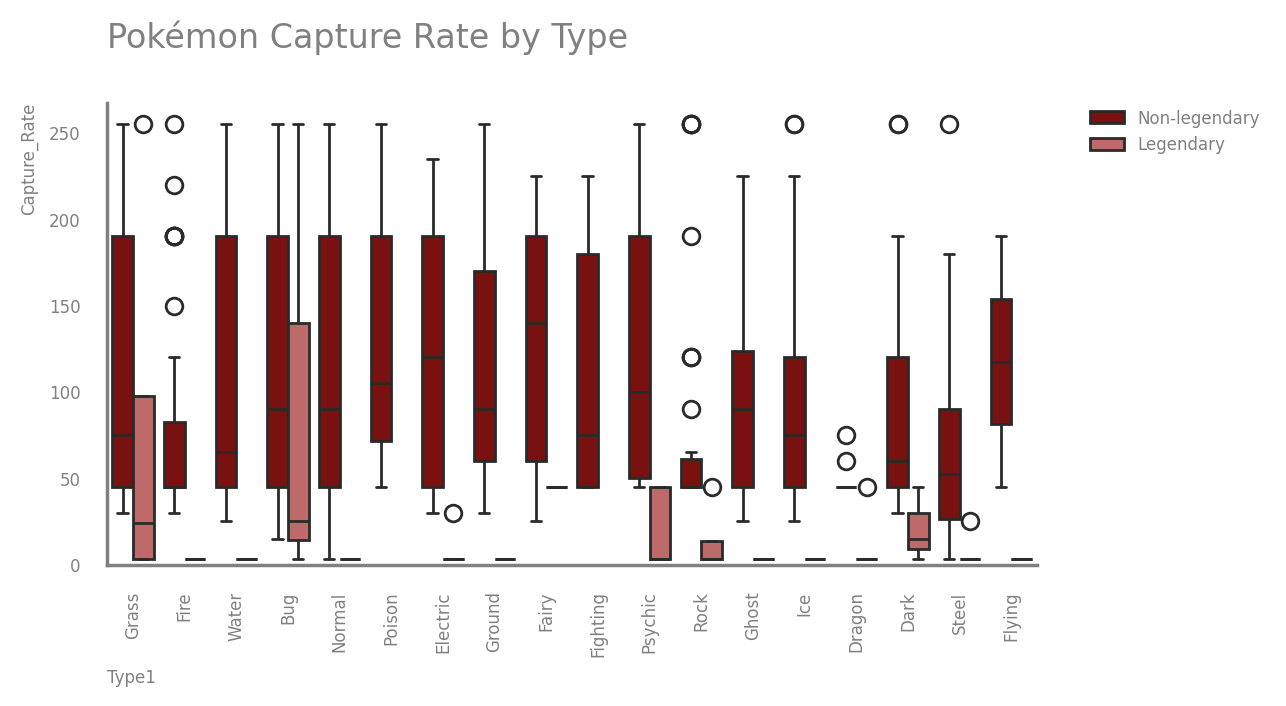

In [29]:
ax=sns.boxplot(
        df,
        x= 'Type1',
        y= 'Capture_Rate',
        hue= 'Is_Legendary',
        palette= ['darkred', 'indianred']
    )
ax.set_title('Pokémon Capture Rate by Type')
plt.ylim(bottom=0)
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
sns.despine()

#### Narysuj wykres słupkowy.
***
Stwórz wykres słupkowy, który przedstawia top 10 Pokémonów z najlepszym łącznym wynikiem bazowych statystyk (`'Base_Total'`).

In [ ]:
top10_pokemon_base_total = df.loc[:, ['Name', 'Base_Total']].sort_values(
    by='Base_Total',
    ascending=False,
)[:10].reset_index()

top10_pokemon_base_total

,index,Name,Base_Total
0,383,Rayquaza,780
1,149,Mewtwo,780
2,381,Kyogre,770
3,382,Groudon,770
4,492,Arceus,720
5,717,Zygarde,708
6,718,Diancie,700
7,380,Latios,700
8,372,Salamence,700
9,444,Garchomp,700


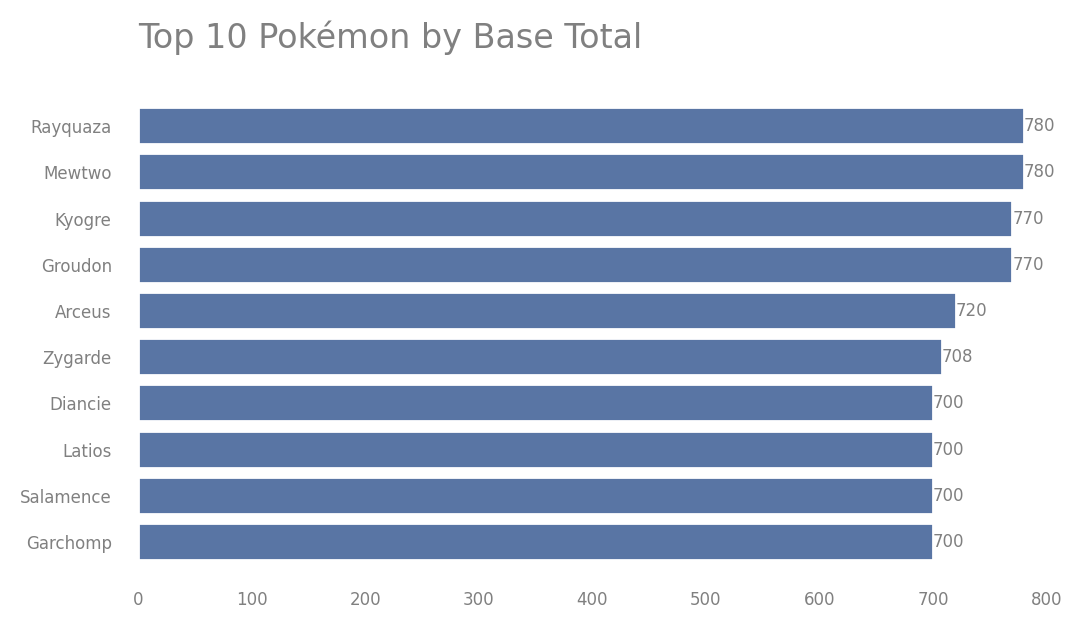

In [39]:
ax = sns.barplot(x="Base_Total", y="Name", data=top10_pokemon_base_total)

ax.set_title('Top 10 Pokémon by Base Total')
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(top=True, bottom=True, left=True, right=True)

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.show()

#### Usuń niepotrzebne kolumny.
***
Zanim przejdziemy do dalszego etapu, gdzie będziemy wizualizować dane za pomocą widgetów, wyrzućmy 20 początkowych kolumn (poza pierwszą kolumną `'Name'`), które nie zawierają ważnych informacji.

Dla zainteresowanych te kolumny to:

`['Abilities', 'Against_Bug', 'Against_Dark', 'Against_Dragon', 'Against_Electric', 'Against_Fairy', 'Against_Fight', 'Against_Fire', 'Against_Flying', 'Against_Ghost', 'Against_Grass', 'Against_Ground', 'Against_Ice', 'Against_Normal', 'Against_Poison', 'Against_Psychic', 'Against_Rock', 'Against_Steel', 'Against_Water']`

In [40]:
df = df.drop(df.iloc[:,1:20], axis=1)

#### Stwórz Dashboard do wyświetlania i filtrowania DataFrame'a.
***
Chcemy stworzyć dashboard bardzo podobny do tego, który stworzyliśmy w notebooku `SI_4.ipynb`, ale tym razem na danych dotyczących Pokémonów.

Najpierw potrzebujemy dwóch rozwijanych list: `'Generation'` (generacja) oraz `'Type1'` (pierwotny typ).
Uważaj na to, czy nazwy kolumn rozpoczynają się z wielkiej, czy małej litery.

Potrzebujemy również pola tekstowego do wprowadzania liczb z ograniczeniami, które będzie zmieniać kolorowanie kolumn: `['Attack', 'Defense', 'Sp_Attack', 'Sp_Defense', 'Speed']`.

Dodatkowo potrzebujemy wyjścia, które będzie wyświetlać przefiltrowany DataFrame (`output`), oraz wyjścia, które będzie wyświetlać wykres KDE (Kernel Density Estimation) dla kolumny `'Base_Total'` (`plot_output`).

Chcemy również stworzyć funkcję do filtrowania danych, która pobiera wartości z trzech widgetów i filtruje dane z DataFrame'a na podstawie wybranych wartości.

Następnie dodamy trzy funkcje reagujące na zdarzenia i trzy funkcje obserwujące widgety, które wywołują funkcję `common_filtering` z odpowiednimi argumentami, gdy wartość widgetu zostanie zmieniona.

Na koniec połączymy wszystkie widgety i wyjścia w jeden dashboard. W jednej zakładce wyświetlany będzie DataFrame, a w drugiej wykres KDE.


#### Stwórz Dashboard do rysowania i zmieniania wykresów.
***
Naszym drugim zadaniem jest opracowanie Dashboardu, który umożliwi nam tworzenie wykresów na podstawie dostępnych danych oraz zapewni możliwość modyfikowania właściwości wykresów. W naszym Dashboardzie chcemy uwzględnić następujące elementy (widgetów):

- Wywoływanie funkcji rysującej
    - Przycisk - służy do wywołania funkcji rysującej wykres.

- Wybór danych na obu osiach (tylko dane numeryczne!)
    - Rozwijana lista - służy do wyboru kolumny zawierającej dane dla osi X na wykresie.

    - Rozwijana lista - służy do wyboru kolumny zawierającej dane dla osi Y na wykresie.

- Nadawanie tytułu i nazw osi
    - Pole tekstowe - służy do wprowadzenia tytułu wykresu.

    - Pole tekstowe - służy do wprowadzenia nazwy osi X.

    - Pole tekstowe - służy do wprowadzenia nazwy osi Y.

- Usuwanie obramowania (`despine`)
    - Zestaw czterech pól wyboru - służą do wyboru, które obramowania wykresu mają być usunięte (opcje to "Top", "Bottom", "Left" i "Right").


-  Ustalanie zakresu danych na osiach
    - Suwak - służy do ustawienia zakresu osi X na wykresie w procentach.

    - Suwak - służy do ustawienia zakresu osi Y na wykresie w procentach.

    - Pole wyboru - służy do wyboru, czy ustawić zakres osi X od 0.

    - Pole wyboru - służy do wyboru, czy ustawić zakres osi Y od 0.

-  Stylowanie
    - Pole wyboru - służy do obrotu etykiet osi x.

    - `ColorPicker` - służy do wyboru koloru wykresu.

    - Przycisk - służy do włączania i wyłączania siatki na wykresie.

    - Przyciski przełączające (`ToggleButtons`) - służą do zmiany stylu wykresu. Opcje to 'white', 'dark', 'whitegrid', 'darkgrid', 'ticks'.

Teraz musimy napisać funkcję, która będzie wywoływana przy naciśnięciu przycisku i będzie rysować nasz wykres.

W dużym uproszczeniu funkcja powinna sprawdzać wartości poszczególnych widgetów i w zależności od ich wartości modyfikować sposób rysowania funkcji.

Co do rodzaju rysowanego wykresu, pozostawiam dowolność, aczkolwiek na początek polecam `regplot` albo `scatterplot`, ponieważ nie powinno być z nimi problemu, jeśli chodzi o rodzaj danych. Potem oczywiście można bardzo łatwo zmienić rodzaj wykresu albo dodać możliwość wyboru rodzaju wykresu.

Podpowiedź
Przyda się napisanie funkcji pomocniczej, która pobiera wartości pól wyboru, które obramowania wykresu mają być usunięte (`despine`). Funkcja powinna zwracać słownik, który wygląda mniej więcej tak:

`słownik = {"top":True, "bottom":False, "left":False, "right":True}`

Dzięki takiemu słownikowi można łatwo wywołać funkcję, która usuwa obramowanie:

`sns.despine(**słownik)`

Na końcu naszym celem jest połączenie trzech elementów w jeden spójny Dashboard.

Pierwszy element to zestaw widgetów, które pozwolą nam na modyfikowanie właściwości wykresów. Planujemy podzielić je na dwie grupy i umieścić w oddzielnych zakładkach - Plot oraz Styling.

Drugi element to przycisk, który po kliknięciu wywoła generowanie wykresu.

Trzeci element to wyjście (Output), gdzie będzie wyświetlany nasz wygenerowany wykres.